In [1]:
from xaikd import models, attributors, datasets

from torch.nn import functional as F

import torch

import torchvision


from matplotlib import pyplot as plt

In [2]:
# model = models.get_trained_model("imagenet-vgg16bn-tv")

# assert not model.training
# model

In [3]:

torchvision.models.vgg16_bn(weights=torchvision.models.vgg.VGG16_BN_Weights.IMAGENET1K_V1)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

# explaining

In [4]:
ds = datasets.construct("imagenet-butterfly")

ds_val = ds.create_subset(train_split=False)

ds_val.transform = lambda x: x

We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2926258.60it/s]


In [5]:
input_transform = ds.input_transformation

input_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [6]:
from torchvision import transforms

rc_transform = transforms.Compose(
    [transforms.Resize(256), transforms.CenterCrop(224)]
)

In [7]:
from matplotlib.colors import ListedColormap
import numpy as np

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    fontsize=None,
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)
    if total_score is None:
        percent = 100
        txt = r"$\sum_i R_i=%.2f$" % (sum_Ri)
    else:
        percent = (sum_Ri / total_score) * 100
        txt = r"$\sum_i R_i=%.4f$ (%3.1f%%)" % (sum_Ri, percent)

    plt.axis("on")
    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

    h = heatmap.shape[0]
    
    plt.title(f"{title}", fontsize=fontsize)
    if logit is not None:
        plt.xlabel(f"{txt}, logit={logit:.4f}", fontsize=fontsize)
    else:
        plt.xlabel(f"{txt}", fontsize=fontsize)

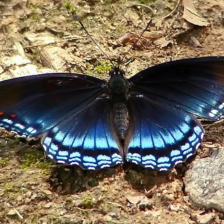

In [8]:
from PIL import Image

image = Image.open("../2024-02-s21/admiral.jpg")

image, label = ds_val[1]

assert label == 0

rc_transform(image)

In [9]:
import pandas as pd
IMAGENET_CLASSNAMES = pd.read_csv("../../imagenet-label-mapping.csv")["desc"].values

IMAGENET_CLASSNAMES

array(['tench', 'goldfish', 'great_white_shark', 'tiger_shark',
       'hammerhead', 'electric_ray', 'stingray', 'cock', 'hen', 'ostrich',
       'brambling', 'goldfinch', 'house_finch', 'junco', 'indigo_bunting',
       'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water_ouzel',
       'kite', 'bald_eagle', 'vulture', 'great_grey_owl',
       'European_fire_salamander', 'common_newt', 'eft',
       'spotted_salamander', 'axolotl', 'bullfrog', 'tree_frog',
       'tailed_frog', 'loggerhead', 'leatherback_turtle', 'mud_turtle',
       'terrapin', 'box_turtle', 'banded_gecko', 'common_iguana',
       'American_chameleon', 'whiptail', 'agama', 'frilled_lizard',
       'alligator_lizard', 'Gila_monster', 'green_lizard',
       'African_chameleon', 'Komodo_dragon', 'African_crocodile',
       'American_alligator', 'triceratops', 'thunder_snake',
       'ringneck_snake', 'hognose_snake', 'green_snake', 'king_snake',
       'garter_snake', 'water_snake', 'vine_snake', 'night_snake',
     

In [15]:
from torch import nn

from xaikd import utils

from collections import OrderedDict

In [ ]:
utils.modules.merge_conv_and_bn

In [49]:
def canonize(model):
    
    features = []
    for ix, module in enumerate(model.features.children()):
#         print(f"ix={ix}; len(features)={len(features)}")
        
        last_ix = len(features)
        if isinstance(module, nn.BatchNorm2d):
            features[last_ix-1] = utils.modules.merge_conv_and_bn(
                features[last_ix-1],
                module
            )
        else:
            features.append(module)
         
    
    return nn.Sequential(
        OrderedDict([
            ("features", nn.Sequential(*features)),
            ("avgpool", model.avgpool),
            ("flatten", nn.Flatten(start_dim=1)),
            ("classifier", model.classifier)
        ])
    )
    

@torch.no_grad()
def ano():
    
    x = torch.randn(5, 3, 224, 224)
    
    model = models.get_trained_model("imagenet-vgg16bn-tv")
    
    can_model = canonize(model)
    
    actual = can_model(x)
    
    expected = models.get_trained_model("imagenet-vgg16bn-tv")(x)

    np.testing.assert_allclose(
        actual.numpy(),
        expected.numpy(),
        atol=1e-5
    )
    
    print("sanity check passed")
    return can_model

ano()

sanity check passed


Sequential(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dil

In [50]:
def get_model(model_name):
    if model_name in ["imagenet-vgg16-tv", "imagenet-vgg16bn-tv"]:
        return models.get_trained_model(model_name)
    elif model_name == "imagenet-vgg16bnc-tv":
        print("manually canomized model")
        model = get_model("imagenet-vgg16bn-tv")
        return canonize(model)
    
get_model("imagenet-vgg16bnc-tv")

manually canomized model


Sequential(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dil

Canonizers: [<zennit.torchvision.VGGCanonizer object at 0x7f5c096c8490>]


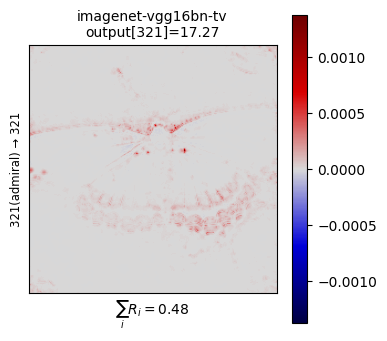

In [51]:
def viz(model_name, img, label, arr_class_descs, title="", show_colorbar=True):
    
    num_classes = len(arr_class_descs)
    
    model = get_model(model_name)
        
    data = input_transform(img)[None]
    
    logit_mod = lambda logits: logits * F.one_hot(torch.Tensor([label]).long(), num_classes)

    # create the attributor, specifying model
    with attributors.make_attributor_for(
        model,
        input_statistics=[input_transform.mean, input_transform.std]
    ) as attributor:
        output, attribution = attributor(data, logit_mod)
        
    
    heatmap = attribution.numpy().sum(axis=1).squeeze()
    
    output = output.squeeze().detach().cpu().numpy()
    if num_classes < 1000:
        print("output:", output)
            
    ypred = np.argmax(output)
        
    plt.figure(figsize=(4, 4))
    desc = arr_class_descs[label]
    _heatmap(
        heatmap, 
        title=f"{model_name}\noutput[{label}]={output[label]:.4}"
    )
    plt.ylabel(
        f"{label}({desc}) → {ypred}",
        fontsize="small"
    )
    
    if show_colorbar:

        plt.colorbar()
    
    
viz("imagenet-vgg16bn-tv", img=image, label=321, arr_class_descs=IMAGENET_CLASSNAMES)

manually canomized model
Canonizers: []


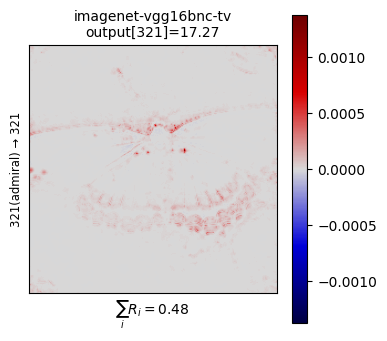

In [52]:
viz("imagenet-vgg16bnc-tv", img=image, label=321, arr_class_descs=IMAGENET_CLASSNAMES)

Canonizers: []


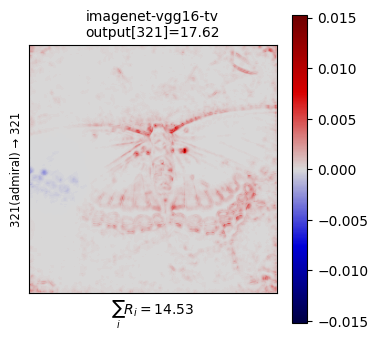

In [53]:
viz("imagenet-vgg16-tv", img=image, label=321, arr_class_descs=IMAGENET_CLASSNAMES)